# Fitting NS1 auditory cortical responses with StateNet

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/urancon/deepSTRF/blob/develop/examples/fit_ns1_statenet.ipynb)

This notebook is the canonical end-to-end demo of deepSTRF:
**dataset → model → metrics → training**. It uses the **NS1** dataset
(Harper et al. 2016, Rahman et al. 2020; auto-downloaded from OSF +
the DNet companion repo) and a **StateNet GRU** encoding model
(Rahman, Willmore et al. 2020), trained with the deepSTRF
[`Fitter`](../docs/_source/md/fitter.md).

What you'll see:

1. Auto-download and inspect NS1 (119 ferret A1 cells, 20 nat. sound clips, R=20 reps).
2. Train/val/test split by stimulus (14 / 3 / 3).
3. Build a StateNet GRU population model (one model fits all 119 cells jointly).
4. Train with the `Fitter`, monitoring `val_cc_norm` (Schoppe-style
   noise-corrected correlation; see [`metrics_paradigm.md`](../docs/_source/md/metrics_paradigm.md) §6.4).
5. Evaluate on the held-out test stimuli and visualise predictions vs PSTHs.

Reference numbers for orientation: published mean `cc_norm` for
StateNet on NS1 is ~0.7–0.8 with leave-one-out training; this minimal
14-stim train set lands in the same neighbourhood.


## Setup — Google Colab

If you're running on Google Colab, the cell below installs deepSTRF
from source. On a local install (`pip install -e .`) it's a no-op.

In [ ]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q git+https://github.com/urancon/deepSTRF.git
    print("deepSTRF installed from GitHub.")
else:
    print("Local environment — assuming deepSTRF is already importable.")


## Imports

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

from deepSTRF.datasets.audio.ns1_drc import NS1Dataset
from deepSTRF.models.audio import StateNet
from deepSTRF.metrics import corrcoef, normalized_corrcoef
from deepSTRF.training import Fitter, set_random_seed
from deepSTRF.utils.data import neural_collate

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
set_random_seed(0)


Using device: cuda


## 1. Load NS1

`NS1Dataset(download=True)` fetches metadata, raw spike data, and the
precomputed 5 ms mel-spectrogram from public OSF + GitHub repos
(~160 MB, no account needed). Subsequent loads use the cached copy
under `~/.cache/deepSTRF/NS1`.

In [2]:
ds = NS1Dataset(dt_ms=5.0, smooth=True, download=True)
print(f"Cells:      {ds.N_neurons}")
print(f"Stimuli:    {len(ds.stims)}")
print(f"Spec shape: {tuple(ds.stims[0].shape)}  (1, F, T) at dt=5 ms")
print(f"Resp shape: {tuple(ds.responses[0][0].shape)}  (R, T) per (stim, neuron)")
print(f"Stim types: {sorted(set(m['type'] for m in ds.stim_meta))}")


Cells:      119
Stimuli:    20
Spec shape: (1, 34, 999)  (1, F, T) at dt=5 ms
Resp shape: (20, 999)  (R, T) per (stim, neuron)
Stim types: ['ferret_vocalization', 'human_speech', 'insects_buzzing', 'unknown', 'water_sounds']


## 2. Quick look — one stim, one cell

The stimulus is a 4.995-s 34-band mel spectrogram. The response is
20 trial repeats binned at 5 ms, smoothed with a 21 ms Hanning
window (Hsu, Borst & Theunissen 2004 convention).

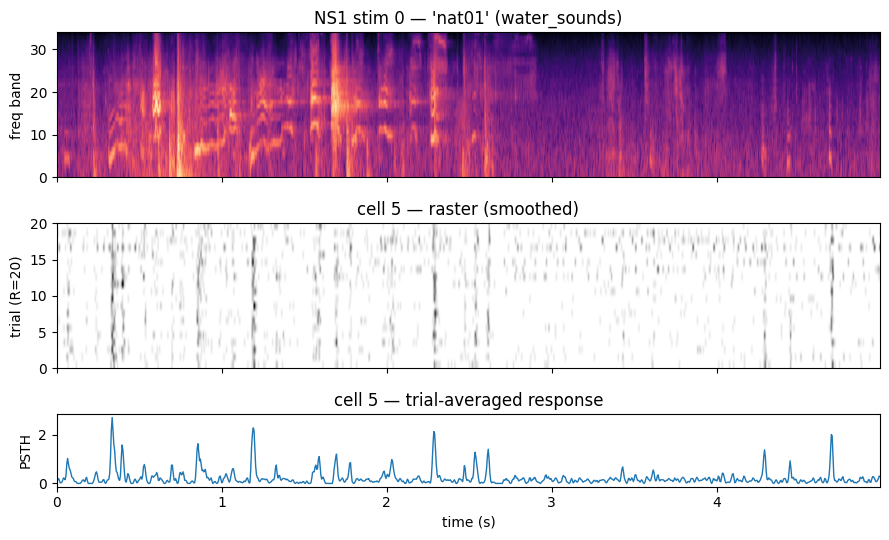

PSTH range: [0.000, 2.700]  mean: 0.224


In [3]:
fig, axs = plt.subplots(3, 1, figsize=(9, 5.5), sharex=True,
                        gridspec_kw={"height_ratios": [2, 2, 1]})
stim_idx, cell_idx = 0, 5
spec = ds.stims[stim_idx][0].numpy()              # (F, T)
resp = ds.responses[stim_idx][cell_idx].numpy()   # (R, T)
psth = resp.mean(axis=0)
t = np.arange(spec.shape[1]) * 5e-3                # seconds

axs[0].imshow(spec, aspect="auto", origin="lower", cmap="magma",
              extent=[t[0], t[-1], 0, 34])
axs[0].set_ylabel("freq band")
axs[0].set_title(f"NS1 stim {stim_idx} — '{ds.stim_meta[stim_idx]['name']}' ({ds.stim_meta[stim_idx]['type']})")

axs[1].imshow(resp, aspect="auto", cmap="Greys",
              extent=[t[0], t[-1], 0, resp.shape[0]])
axs[1].set_ylabel(f"trial (R={resp.shape[0]})")
axs[1].set_title(f"cell {cell_idx} — raster (smoothed)")

axs[2].plot(t, psth, lw=1.0)
axs[2].set_ylabel("PSTH")
axs[2].set_xlabel("time (s)")
axs[2].set_title(f"cell {cell_idx} — trial-averaged response")
plt.tight_layout()
plt.show()
print(f"PSTH range: [{psth.min():.3f}, {psth.max():.3f}]  mean: {psth.mean():.3f}")


## 3. Train / val / test split

For this minimal demo we hold out 3 stims for validation and 3 for
test. The published NS1 protocol uses leave-one-out cross-validation
across all 20 stims; the same `Fitter`-based code generalises to
that with an outer loop over splits.

In [4]:
train_idx = list(range(14))           # stims 0..13
val_idx   = list(range(14, 17))       # 14, 15, 16
test_idx  = list(range(17, 20))       # 17, 18, 19

train_loader = DataLoader(Subset(ds, train_idx), batch_size=1,
                          shuffle=True, collate_fn=neural_collate)
val_loader   = DataLoader(Subset(ds, val_idx),   batch_size=1,
                          shuffle=False, collate_fn=neural_collate)
test_loader  = DataLoader(Subset(ds, test_idx),  batch_size=1,
                          shuffle=False, collate_fn=neural_collate)

print(f"train: {len(train_loader.dataset)} stims | "
      f"val: {len(val_loader.dataset)} | "
      f"test: {len(test_loader.dataset)}")


train: 14 stims | val: 3 | test: 3


## 4. Model: StateNet GRU

`StateNet` (Rahman, Willmore et al. 2020) is a per-timestep spectral
encoder followed by a recurrent core (GRU here) and a per-neuron linear
readout. With `out_neurons=119`, one population model jointly fits all
NS1 cells through a shared backbone.

The default output activation is `ParametricSoftplus(out_neurons)` —
per-neuron learnable sharpness β and additive baseline b, both
softplus-reparameterised so the curve stays non-negative. This is
unbounded above (good for spike-count regression where peaks can exceed
1) and the per-neuron parameters let the model adapt the firing curve
per cell. See `deepSTRF.models.activations` for the alternative
parametric variants (`ParametricSigmoid`, `ParametricDoubleExponential`)
or pass `output_activation=nn.Identity()` for an unbounded signed
output.

In [5]:
model = StateNet(
    n_frequency_bands=34,
    hidden_channels=7, kernel_size=7, stride=3,
    connectivity="LC", rnn_type="GRU",
    out_neurons=ds.N_neurons,
)
print(model)
print(f"\nTrainable params: {model.count_trainable_params():,}")


StateNet(
  (wav2spec): Identity()
  (prefiltering): Identity()
  (core): Identity()
  (encoder_layers): Sequential(
    (0): LocallyConnected1d(
      (unfold): Unfold(kernel_size=(7, 1), dilation=1, padding=0, stride=3)
      (fold): Fold(output_size=(10, 1), kernel_size=(1, 1), dilation=1, padding=0, stride=1)
    )
    (1): CausalLayerNorm(
      (ln): LayerNorm((7,), eps=1e-05, elementwise_affine=True)
    )
    (2): Sigmoid()
  )
  (rnn): GRU(70, 70, batch_first=True)
  (readout): LinearReadout(
    (fc): Linear(in_features=70, out_features=119, bias=True)
    (activation): ParametricSoftplus(N=119, non_negative_output=True)
  )
)

Trainable params: 39,081


## 5. Train with the Fitter

The `Fitter` wires a model, the loaders, an optimizer, and the
canonical val metrics (`cc`, `cc_norm`) into a single `.fit()` call.
Defaults match `metrics_paradigm.md` §7: `mse_loss` against the auto-PSTH
of `responses`, `monitor='val_cc_norm'` with `mode='max'`, and AdamW
with `lr=1e-3`. We override `weight_decay=0.0` to match the legacy NS1
convention.

In [6]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)

fitter = Fitter(
    model, train_loader, val_loader,
    optimizer=optimizer,
    device=device,
    max_epochs=80,
    patience=15,
    monitor="val_cc_norm",
    mode="max",
    log_fn=lambda d: print(
        f"epoch {d['epoch']:3d}  "
        f"train_loss={d['train_loss']:.4f}  "
        f"val_loss={d['val_loss']:.4f}  "
        f"val_cc_norm={torch.nanmean(d['val_cc_norm']):+.3f}",
        flush=True,
    ),
)
history = fitter.fit()
print(f"\nfinished after {len(history)} epochs")


epoch   0  train_loss=0.0305  val_loss=0.0204  val_cc_norm=+0.112


epoch   1  train_loss=0.0244  val_loss=0.0192  val_cc_norm=+0.161


epoch   2  train_loss=0.0236  val_loss=0.0189  val_cc_norm=+0.204


epoch   3  train_loss=0.0230  val_loss=0.0185  val_cc_norm=+0.250


epoch   4  train_loss=0.0224  val_loss=0.0185  val_cc_norm=+0.293


...

epoch  76  train_loss=0.0114  val_loss=0.0110  val_cc_norm=+0.804


epoch  77  train_loss=0.0112  val_loss=0.0108  val_cc_norm=+0.810


epoch  78  train_loss=0.0112  val_loss=0.0107  val_cc_norm=+0.811


epoch  79  train_loss=0.0112  val_loss=0.0108  val_cc_norm=+0.811



finished after 80 epochs


## 6. Training curves

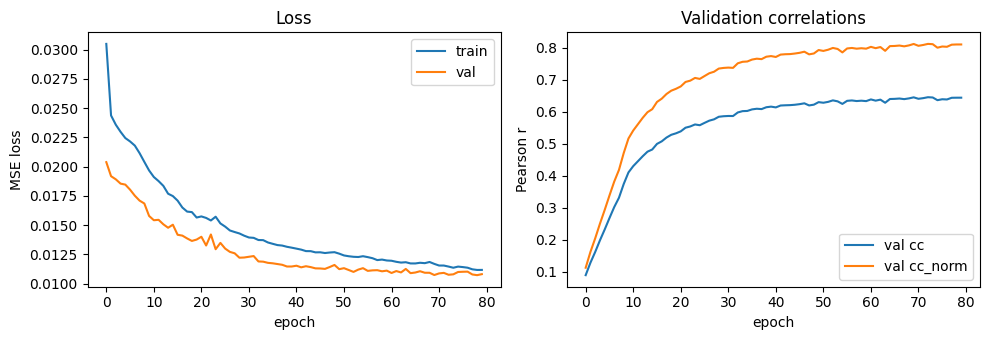

In [7]:
epochs = [h["epoch"] for h in history]
train_loss = [h["train_loss"] for h in history]
val_loss = [h["val_loss"] for h in history]
val_cc = [torch.nanmean(h["val_cc"]).item() for h in history]
val_ccn = [torch.nanmean(h["val_cc_norm"]).item() for h in history]

fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))
axs[0].plot(epochs, train_loss, label="train", lw=1.5)
axs[0].plot(epochs, val_loss, label="val", lw=1.5)
axs[0].set_xlabel("epoch"); axs[0].set_ylabel("MSE loss"); axs[0].legend()
axs[0].set_title("Loss")

axs[1].plot(epochs, val_cc, label="val cc",       lw=1.5)
axs[1].plot(epochs, val_ccn, label="val cc_norm", lw=1.5)
axs[1].set_xlabel("epoch"); axs[1].set_ylabel("Pearson r"); axs[1].legend()
axs[1].set_title("Validation correlations")
plt.tight_layout(); plt.show()


## 7. Test-set evaluation

`fitter.evaluate(loader)` runs the same cross-batch concat-then-compute
pipeline on the held-out stims and returns un-prefixed metrics.

In [8]:
test_metrics = fitter.evaluate(test_loader)
test_cc = test_metrics["cc"].cpu()
test_ccn = test_metrics["cc_norm"].cpu()
print(f"test loss:       {test_metrics['loss']:.4f}")
print(f"test cc      mean={torch.nanmean(test_cc):+.3f}  median={torch.nanmedian(test_cc):+.3f}")
print(f"test cc_norm mean={torch.nanmean(test_ccn):+.3f}  median={torch.nanmedian(test_ccn):+.3f}")


test loss:       0.0160
test cc      mean=+0.659  median=+0.681
test cc_norm mean=+0.770  median=+0.796


## 8. Per-cell `cc_norm` distribution

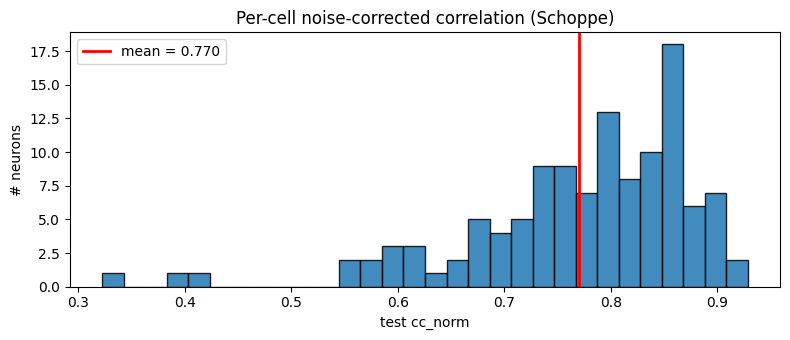

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(test_ccn.numpy(), bins=30, edgecolor="black", alpha=0.85)
ax.axvline(torch.nanmean(test_ccn).item(), color="red", lw=2,
           label=f"mean = {torch.nanmean(test_ccn):.3f}")
ax.set_xlabel("test cc_norm")
ax.set_ylabel("# neurons")
ax.set_title("Per-cell noise-corrected correlation (Schoppe)")
ax.legend()
plt.tight_layout(); plt.show()


## 9. Predictions vs ground-truth PSTH

Pick the best, median, and worst cells (by test `cc_norm`) and overlay
the model's prediction on the trial-averaged response for one held-out
stimulus.

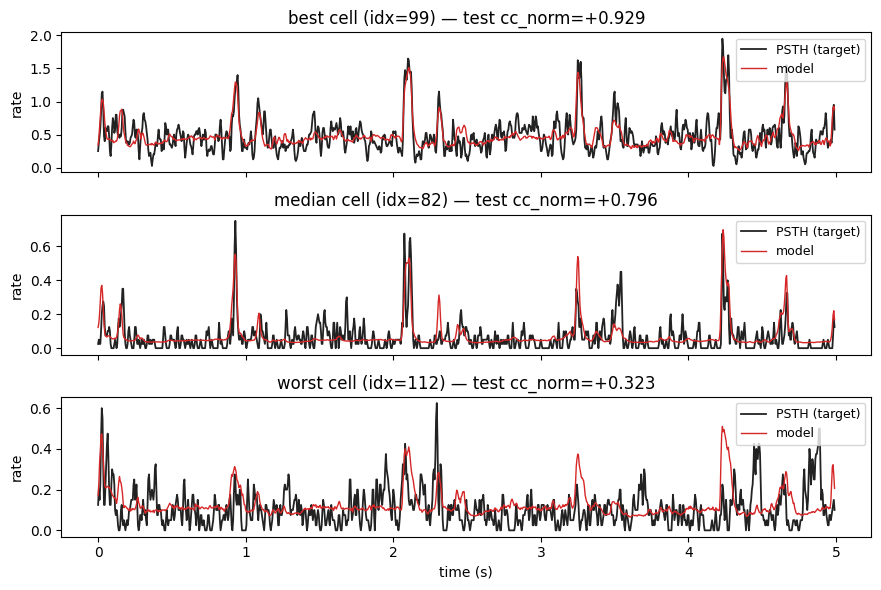

In [10]:
# rank cells by cc_norm; pick best / median / worst
ranking = test_ccn.argsort(descending=True)
best, median, worst = ranking[0].item(), ranking[len(ranking) // 2].item(), ranking[-1].item()
picks = [("best",   best),
         ("median", median),
         ("worst",  worst)]

# run inference on test stim 0
model.eval()
with torch.no_grad():
    stim0 = ds.stims[test_idx[0]].unsqueeze(0).to(device)        # (1, 1, F, T)
    pred  = model(stim0).cpu().squeeze(0).squeeze(1)             # (N, T)

# trial-averaged response per cell on the same stim
psth_per_cell = torch.stack([r.mean(dim=0) for r in ds.responses[test_idx[0]]])  # (N, T)

t = np.arange(pred.shape[1]) * 5e-3
fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for ax, (label, idx) in zip(axs, picks):
    ax.plot(t, psth_per_cell[idx].numpy(), label="PSTH (target)", lw=1.3, color="#222")
    ax.plot(t, pred[idx].numpy(),         label="model",          lw=1.0, color="#d62728")
    ax.set_ylabel("rate")
    ax.set_title(f"{label} cell (idx={idx}) — test cc_norm={test_ccn[idx]:+.3f}")
    ax.legend(loc="upper right", fontsize=9)
axs[-1].set_xlabel("time (s)")
plt.tight_layout(); plt.show()


## What's next

- **Other audio datasets** — same `Fitter`/metrics stack works on
  CRCNS AA1/AA2/AA4 and NAT4 with no code changes; only the
  dataset constructor differs.
- **Cross-species concatenation** — `concat_neural_datasets([ns1, aa1])`
  builds a block-diagonal joint dataset; a single StateNet over the
  union fits both species jointly. See
  [`dataset_concatenation.md`](../docs/_source/md/dataset_concatenation.md).
- **Custom training loops** — the `Fitter` is a thin convenience; for
  multi-GPU, mixed-precision, gradient accumulation, etc., write the
  3-line canonical loop from
  [`metrics_paradigm.md`](../docs/_source/md/metrics_paradigm.md) §7
  directly.
